# Task 2 — Part B: Proposed GNN Model

## Cell 1 — Imports

In [1]:
# OURPROJECT IMPLEMENTATION


import time, json, warnings, re
import subprocess, sys
warnings.filterwarnings("ignore")

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "torch-geometric"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

FEATURE_PATH = Path("/kaggle/input/datasets/tahu663/putemg-window-feature-dataset-parquet/putemg_window_feature_dataset.parquet")
SPLIT_PATH = Path("/kaggle/input/datasets/tahu663/task2-baseline-info/split_info.json")
BASELINE_RESULTS_PATH = Path("/kaggle/input/datasets/tahu663/task2-baseline-info/baseline_results.csv")
OUTPUT_FOLDER = Path("/kaggle/working/task2_proposed")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

GESTURE_NAMES = {
    0: "Idle",        1: "Fist",
    2: "Flexion",     3: "Extension",
    6: "Pinch-Index", 7: "Pinch-Middle",
    8: "Pinch-Ring",  9: "Pinch-Small",
}

print("Imports done.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.3 MB/s eta 0:00:00
Imports done.
PyTorch version : 2.10.0+cu128
CUDA available  : True


## Cell 2 — Load Dataset and Reproduce Exact Split



In [2]:
# Load prepared putEMG feature dataset
feature_df = pd.read_parquet(FEATURE_PATH)

print(f"Dataset loaded: {feature_df.shape}")

# Load EXACT split saved by baseline notebook
assert SPLIT_PATH.exists(), (
    f"split_info.json not found at {SPLIT_PATH}"
)

with open(SPLIT_PATH, "r") as f:
    split_info = json.load(f)

train_subjects = [int(s) for s in split_info["train_subjects"]]
val_subjects   = [int(s) for s in split_info["val_subjects"]]
test_subjects  = [int(s) for s in split_info["test_subjects"]]

# Recreate exact train / validation / test partitions
train_df = feature_df[
    feature_df["subject_id"].isin(train_subjects)
].copy()

val_df = feature_df[
    feature_df["subject_id"].isin(val_subjects)
].copy()

test_df = feature_df[
    feature_df["subject_id"].isin(test_subjects)
].copy()


# Subject-independence checks
assert set(train_subjects).isdisjoint(val_subjects), (
    "Train/validation subject overlap!"
)

assert set(train_subjects).isdisjoint(test_subjects), (
    "Train/test subject overlap!"
)

assert set(val_subjects).isdisjoint(test_subjects), (
    "Validation/test subject overlap!"
)


# Every dataset subject must belong to exactly one partition
dataset_subjects = set(
    int(s) for s in feature_df["subject_id"].unique()
)

split_subjects = (
    set(train_subjects)
    | set(val_subjects)
    | set(test_subjects)
)

assert split_subjects == dataset_subjects, (
    "Subjects in split_info.json do not exactly match dataset subjects."
)


# Every row must be assigned exactly once
assert (
    len(train_df) + len(val_df) + len(test_df)
    == len(feature_df)
), "Some dataset rows were not assigned to train/val/test!"


print("\nSplit loaded from split_info.json")
print(
    f"Train : {len(train_subjects)} subjects, "
    f"{len(train_df):,} windows"
)
print(
    f"Val   : {len(val_subjects)} subjects, "
    f"{len(val_df):,} windows"
)
print(
    f"Test  : {len(test_subjects)} subjects, "
    f"{len(test_df):,} windows"
)
print("Subject-independence check passed.")


# Validate baseline-results file BEFORE expensive GNN training
assert BASELINE_RESULTS_PATH.exists(), (
    f"baseline_results.csv not found at {BASELINE_RESULTS_PATH}"
)

baseline_df = pd.read_csv(BASELINE_RESULTS_PATH)

required_baseline_cols = {
    "Model",
    "Accuracy",
    "Balanced Accuracy",
    "Macro-F1",
    "ROC-AUC",
    "PR-AUC",
    "Train time (s)",
}

missing_cols = required_baseline_cols - set(baseline_df.columns)

assert not missing_cols, (
    f"Missing baseline columns: {missing_cols}"
)

assert baseline_df["Macro-F1"].notna().all(), (
    "Missing Macro-F1 value found in baseline results."
)


best_baseline = baseline_df.loc[
    baseline_df["Macro-F1"].idxmax()
]

baseline_best_f1 = float(
    best_baseline["Macro-F1"]
)

baseline_best_name = str(
    best_baseline["Model"]
)

print(
    f"\nBaseline file verified → "
    f"{baseline_best_name}, "
    f"Macro-F1={baseline_best_f1:.4f}"
)

Dataset loaded: (619479, 196)

Split loaded from split_info.json
Train : 31 subjects, 435,797 windows
Val   : 6 subjects, 85,277 windows
Test  : 7 subjects, 98,405 windows
Subject-independence check passed.

Baseline file verified → MLP (PyTorch), Macro-F1=0.5346


## Cell 3 — Preprocessing




In [3]:
import re

feat_cols = list(split_info["feat_cols"])

# Keep only the 7 GNN node-feature types.
# IEMG is excluded because for fixed 1024-sample windows:
# IEMG = MAV × 1024.
FEAT_PAT_7 = re.compile(
    r"EMG_\d+_(MAV|RMS|STD|VAR|WL|ZC|SSC)",
    re.I
)

feat_cols = [
    c for c in feat_cols
    if FEAT_PAT_7.fullmatch(c)
]

N_CHANNELS = 24
N_METRICS  = 7
METRICS    = ["MAV", "RMS", "STD", "VAR", "WL", "ZC", "SSC"]

assert len(feat_cols) == N_CHANNELS * N_METRICS, (
    f"Expected 168 GNN features, got {len(feat_cols)}"
)

assert all(c in feature_df.columns for c in feat_cols), (
    "One or more saved feature columns are missing from the dataset."
)


expected_feat_cols = [
    f"EMG_{ch}_{metric}"
    for metric in METRICS
    for ch in range(1, N_CHANNELS + 1)
]

assert [c.upper() for c in feat_cols] == [
    c.upper() for c in expected_feat_cols
], (
    "Feature ordering is not the expected metric-major order. "
    "Stopping because the 24×7 node reshape would otherwise be incorrect."
)

print("Feature check passed:")
print(f"  GNN features : {len(feat_cols)}")
print(f"  Nodes        : {N_CHANNELS}")
print(f"  Features/node: {N_METRICS}")
print("  Feature order: metric-major ✓")

# Prepare raw arrays
X_train_raw = train_df[feat_cols].to_numpy(dtype="float32")
X_val_raw   = val_df[feat_cols].to_numpy(dtype="float32")
X_test_raw  = test_df[feat_cols].to_numpy(dtype="float32")

y_train_raw = train_df["label"].to_numpy()
y_val_raw   = val_df["label"].to_numpy()
y_test_raw  = test_df["label"].to_numpy()

# Missing / invalid-value check

assert np.isfinite(X_train_raw).all(), (
    "NaN or Inf found in training features."
)
assert np.isfinite(X_val_raw).all(), (
    "NaN or Inf found in validation features."
)
assert np.isfinite(X_test_raw).all(), (
    "NaN or Inf found in test features."
)

print("Missing/non-finite value check passed.")

# VarianceThreshold — FIT TRAIN ONLY
vt = VarianceThreshold(threshold=0.0)

X_train_vt = vt.fit_transform(X_train_raw)
X_val_vt   = vt.transform(X_val_raw)
X_test_vt  = vt.transform(X_test_raw)

# GNN requires exactly the same 7 measurements for every one of 24 nodes.
# The completed baseline removed zero features, so this should remain 168.
assert X_train_vt.shape[1] == 168, (
    f"VarianceThreshold reduced the feature count to "
    f"{X_train_vt.shape[1]}. "
    "Stopping because this would break the 24×7 graph representation."
)

assert X_val_vt.shape[1] == 168
assert X_test_vt.shape[1] == 168

print(
    f"Variance filter passed: "
    f"{X_train_raw.shape[1]} → {X_train_vt.shape[1]} features"
)

# RobustScaler — FIT TRAIN ONLY
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train_vt).astype("float32")
X_val   = scaler.transform(X_val_vt).astype("float32")
X_test  = scaler.transform(X_test_vt).astype("float32")

print(
    f"Scaled shapes → "
    f"Train: {X_train.shape}  "
    f"Val: {X_val.shape}  "
    f"Test: {X_test.shape}"
)


# LabelEncoder — FIT TRAIN ONLY
le = LabelEncoder()

y_train = le.fit_transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

n_classes = len(le.classes_)

# Must match the labels saved by the baseline notebook.
assert [int(c) for c in le.classes_] == [
    int(c) for c in split_info["label_classes"]
], (
    "LabelEncoder classes do not match the baseline experiment."
)

assert n_classes == 8, (
    f"Expected 8 gesture classes, found {n_classes}."
)

class_names = [
    GESTURE_NAMES[c]
    for c in le.classes_
]

print(f"Classes ({n_classes}): {class_names}")


# Class weights — TRAIN LABELS ONLY
cw_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

cw_tensor = torch.tensor(
    cw_values,
    dtype=torch.float32
)

print(
    "Class weights:",
    dict(zip(class_names, cw_values.round(2)))
)


# Final preprocessing verification
assert X_train.shape[1] == N_CHANNELS * N_METRICS
assert X_val.shape[1]   == N_CHANNELS * N_METRICS
assert X_test.shape[1]  == N_CHANNELS * N_METRICS

print("\nCell 3 preprocessing completed successfully.")
print("All preprocessing was fitted using TRAIN subjects only.")
print("Validation and test subjects were transformed only — no leakage.")

Feature check passed:
  GNN features : 168
  Nodes        : 24
  Features/node: 7
  Feature order: metric-major ✓
Missing/non-finite value check passed.
Variance filter passed: 168 → 168 features
Scaled shapes → Train: (435797, 168)  Val: (85277, 168)  Test: (98405, 168)
Classes (8): ['Idle', 'Fist', 'Flexion', 'Extension', 'Pinch-Index', 'Pinch-Middle', 'Pinch-Ring', 'Pinch-Small']
Class weights: {'Idle': np.float64(0.2), 'Fist': np.float64(2.16), 'Flexion': np.float64(2.18), 'Extension': np.float64(2.27), 'Pinch-Index': np.float64(2.29), 'Pinch-Middle': np.float64(2.27), 'Pinch-Ring': np.float64(2.33), 'Pinch-Small': np.float64(2.27)}

Cell 3 preprocessing completed successfully.
All preprocessing was fitted using TRAIN subjects only.
Validation and test subjects were transformed only — no leakage.


## Cell 4 — Graph Construction (Training Subjects Only)


Node representation:
  Train : (435797, 24, 7)
  Val   : (85277, 24, 7)
  Test  : (98405, 24, 7)

Training-only correlation matrix created: (24, 24)


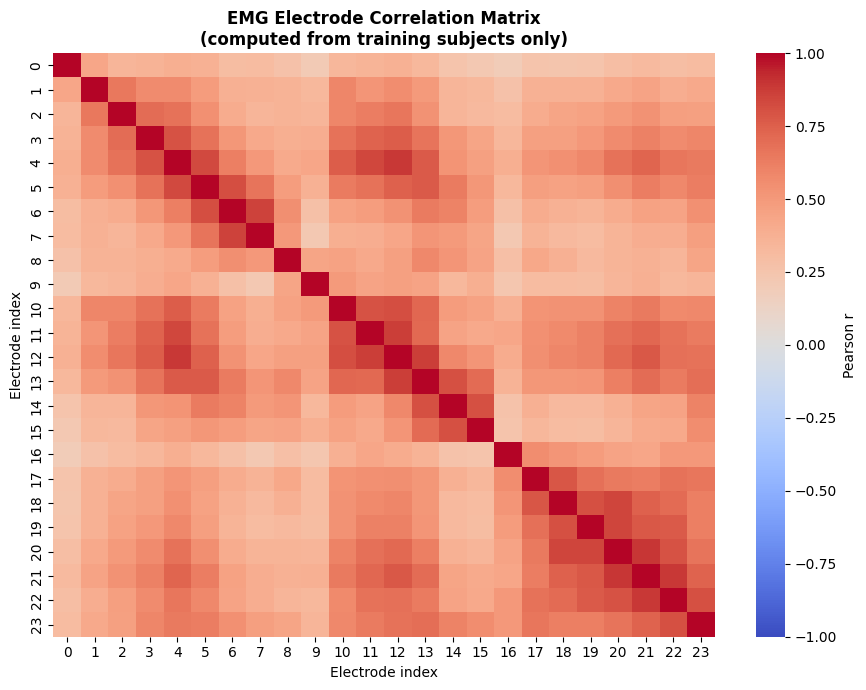

Interpretation: several electrodes show strong inter-channel correlations in the training data, supporting the use of a functional channel graph.

Final graph degree → min=4, max=12, mean=5.83
Each electrode selected its 4 strongest correlations; after symmetrization, final node degree may exceed 4.

Graph summary:
  Nodes              : 24
  Top-K selected     : 4
  Undirected edges   : 70
  PyG edge entries   : 140
  Graph density      : 25.4%

PyG graph tensors:
  edge_index  : torch.Size([2, 140])
  edge_weight : torch.Size([140])
  Weight range: [0.369, 0.895]

Graph weight sanity check passed.
Graph construction completed using TRAINING subjects only.


In [4]:
# Convert flat feature vectors → graph node features
def to_node_features(X):
    """
    Convert:
        (n_windows, 168)
    into:
        (n_windows, 24, 7)

    Cell 3 already verified that columns are metric-major:

        MAV: EMG_1 ... EMG_24
        RMS: EMG_1 ... EMG_24
        ...
        SSC: EMG_1 ... EMG_24

    Therefore:
        reshape → (n, 7, 24)
        transpose → (n, 24, 7)

    Final representation:
        24 electrodes × 7 features per electrode
    """
    return X.reshape(
        -1,
        N_METRICS,
        N_CHANNELS
    ).transpose(0, 2, 1)


X_train_nodes = to_node_features(X_train)
X_val_nodes   = to_node_features(X_val)
X_test_nodes  = to_node_features(X_test)

# Safety checks
assert X_train_nodes.shape == (
    len(X_train), N_CHANNELS, N_METRICS
)
assert X_val_nodes.shape == (
    len(X_val), N_CHANNELS, N_METRICS
)
assert X_test_nodes.shape == (
    len(X_test), N_CHANNELS, N_METRICS
)

print("Node representation:")
print(f"  Train : {X_train_nodes.shape}")
print(f"  Val   : {X_val_nodes.shape}")
print(f"  Test  : {X_test_nodes.shape}")


# Compute electrode correlations using TRAINING SUBJECTS ONLY

ch_mav = X_train_nodes[:, :, 0]

assert ch_mav.shape[1] == N_CHANNELS

corr_matrix = np.corrcoef(ch_mav.T)

assert corr_matrix.shape == (
    N_CHANNELS,
    N_CHANNELS
), "Unexpected correlation-matrix shape."

assert np.isfinite(corr_matrix).all(), (
    "Correlation matrix contains NaN/Inf values."
)

print(
    f"\nTraining-only correlation matrix created: "
    f"{corr_matrix.shape}"
)


# Visualise training-only correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={"label": "Pearson r"}
)

ax.set_title(
    "EMG Electrode Correlation Matrix\n"
    "(computed from training subjects only)",
    fontweight="bold"
)

ax.set_xlabel("Electrode index")
ax.set_ylabel("Electrode index")

plt.tight_layout()
plt.show()

print(
    "Interpretation: several electrodes show strong inter-channel "
    "correlations in the training data, supporting the use of a "
    "functional channel graph."
)


# Top-K graph construction

TOP_K = 4

# Absolute correlation is used as relationship strength.
corr_abs = np.abs(corr_matrix)

adj = np.zeros(
    (N_CHANNELS, N_CHANNELS),
    dtype="float32"
)

for i in range(N_CHANNELS):

    row = corr_abs[i].copy()

    # Exclude the node itself.
    row[i] = -np.inf

    # Four strongest relationships for electrode i
    top_k_idx = np.argsort(row)[-TOP_K:]

    # Store |Pearson r| as the edge weight
    adj[i, top_k_idx] = corr_abs[i, top_k_idx]


# Convert directed Top-K selections into an undirected graph

adj = np.maximum(adj, adj.T)

# No explicit self-loops here
np.fill_diagonal(adj, 0.0)

assert np.allclose(adj, adj.T), (
    "Adjacency matrix is not symmetric."
)

assert np.all(np.diag(adj) == 0), (
    "Unexpected self-loops found in adjacency matrix."
)


# Graph-degree sanity check
degrees = (adj > 0).sum(axis=1)

print(
    f"\nFinal graph degree → "
    f"min={degrees.min()}, "
    f"max={degrees.max()}, "
    f"mean={degrees.mean():.2f}"
)

# Every electrode originally selected TOP_K neighbours.
# After symmetric union, degree may become larger than TOP_K.
assert degrees.min() >= TOP_K, (
    "At least one electrode has fewer than TOP_K effective neighbours."
)

print(
    f"Each electrode selected its {TOP_K} strongest correlations; "
    "after symmetrization, final node degree may exceed "
    f"{TOP_K}."
)


# Graph summary
# Because the adjacency matrix is symmetric, each undirected edge appears twice in PyG edge_index:

n_directed_entries = np.count_nonzero(adj)
n_undirected_edges = n_directed_entries // 2

possible_undirected = (
    N_CHANNELS * (N_CHANNELS - 1) // 2
)

density = (
    100.0
    * n_undirected_edges
    / possible_undirected
)

print(f"\nGraph summary:")
print(f"  Nodes              : {N_CHANNELS}")
print(f"  Top-K selected     : {TOP_K}")
print(f"  Undirected edges   : {n_undirected_edges}")
print(f"  PyG edge entries   : {n_directed_entries}")
print(f"  Graph density      : {density:.1f}%")


# Convert adjacency → PyTorch-Geometric format
rows, cols = np.nonzero(adj)

edge_index = torch.tensor(
    np.stack([rows, cols]),
    dtype=torch.long
)

edge_weight = torch.tensor(
    adj[rows, cols],
    dtype=torch.float32
)


# Final graph-weight checks
assert edge_index.shape[0] == 2

assert edge_index.shape[1] == edge_weight.shape[0], (
    "edge_index and edge_weight sizes do not match."
)

assert torch.isfinite(edge_weight).all(), (
    "edge_weight contains NaN/Inf."
)

assert torch.all(edge_weight >= 0), (
    "Negative edge weights detected."
)

assert torch.all(edge_weight <= 1.0 + 1e-6), (
    "Correlation edge weight greater than 1 detected."
)

assert edge_weight.numel() > 0, (
    "Graph contains no edges."
)

print("\nPyG graph tensors:")
print(f"  edge_index  : {edge_index.shape}")
print(f"  edge_weight : {edge_weight.shape}")
print(
    f"  Weight range: "
    f"[{edge_weight.min().item():.3f}, "
    f"{edge_weight.max().item():.3f}]"
)

print("\nGraph weight sanity check passed.")
print(
    "Graph construction completed using TRAINING subjects only."
)

## Cell 5 — Build PyTorch Geometric Dataset

Each window becomes a graph:
- `x`: node features `(24, 7)`
- `edge_index`: shared topology built from training subjects
- `edge_weight`: correlation strengths
- `y`: gesture label (0–7)


In [5]:
# OUR ORIGINAL PROJECT IMPLEMENTATION

def build_dataset(X_nodes, y_labels):
    """Build list of PyG Data objects. Edge topology is shared across all windows."""
    data_list = []
    for i in range(len(X_nodes)):
        data_list.append(Data(
            x          = torch.tensor(X_nodes[i], dtype=torch.float32),
            edge_index = edge_index,
            edge_attr  = edge_weight.unsqueeze(1),
            y          = torch.tensor(y_labels[i], dtype=torch.long),
        ))
    return data_list

t0         = time.time()
train_data = build_dataset(X_train_nodes, y_train)
val_data   = build_dataset(X_val_nodes,   y_val)
test_data  = build_dataset(X_test_nodes,  y_test)
print(f"Datasets built in {time.time()-t0:.1f}s  —  Train: {len(train_data):,}  Val: {len(val_data):,}  Test: {len(test_data):,}")

sample = train_data[0]
print(f"Sample label : {sample.y.item()} ({class_names[sample.y.item()]})")

BATCH_SIZE   = 512
train_loader = PyGLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = PyGLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = PyGLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)


Datasets built in 24.7s  —  Train: 435,797  Val: 85,277  Test: 98,405
Sample label : 0 (Idle)


## Cell 6 — GCN Model




In [6]:
# OUR ORIGINAL PROJECT IMPLEMENTATION
# Architecture concept: INSPIRED BY Lee et al. (2023) spatial GNN idea
# Their basic GCN: adj = ones/8, bmm(adj, x), matmul(x, W)
# Ours: correlation-weighted edges, GCNConv with edge weights, dual pooling

class CorrGCN(nn.Module):
    """
    Correlation Graph Convolutional Network for putEMG gesture recognition.

    Nodes  : 24 EMG electrodes
    Edges  : top-K Pearson correlation pairs (from training subjects only)
    In-dim : 7 (MAV, RMS, STD, VAR, WL, ZC, SSC)
    """
    def __init__(self, in_dim=7, hidden1=64, hidden2=128,
                 n_classes=8, dropout=0.4):
        super().__init__()
        self.dropout = dropout

        self.conv1 = GCNConv(in_dim,  hidden1)
        self.bn1   = nn.BatchNorm1d(hidden1)

        self.conv2 = GCNConv(hidden1, hidden2)
        self.bn2   = nn.BatchNorm1d(hidden2)

        # Mean + max pooling → hidden2 * 2
        self.fc1   = nn.Linear(hidden2 * 2, 128)
        self.fc_mid= nn.Linear(128, 64)
        self.fc2   = nn.Linear(64, n_classes)

    def forward(self, x, edge_index, edge_weight, batch):
        # x: (total_nodes, 7)

        # GCN Layer 1
        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # GCN Layer 2
        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        x = self.bn2(x)
        x = F.relu(x)

        # Readout: mean + max pooling
        x_mean = global_mean_pool(x, batch)   # (batch, 128)
        x_max  = global_max_pool(x, batch)    # (batch, 128)
        x      = torch.cat([x_mean, x_max], dim=1)  # (batch, 256)

        # MLP classifier
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc_mid(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(self.fc2(x), dim=1)


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = CorrGCN(
    in_dim    = N_METRICS,    # 7
    hidden1   = 64,           # increased from 32
    hidden2   = 128,          # increased from 64
    n_classes = n_classes,    # 8
    dropout   = 0.3,          # reduced from 0.4 — bigger model needs less aggressive dropout
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print()
print(model)


Device: cuda
Trainable parameters: 50,888

CorrGCN(
  (conv1): GCNConv(7, 64)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(64, 128)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc_mid): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=8, bias=True)
)


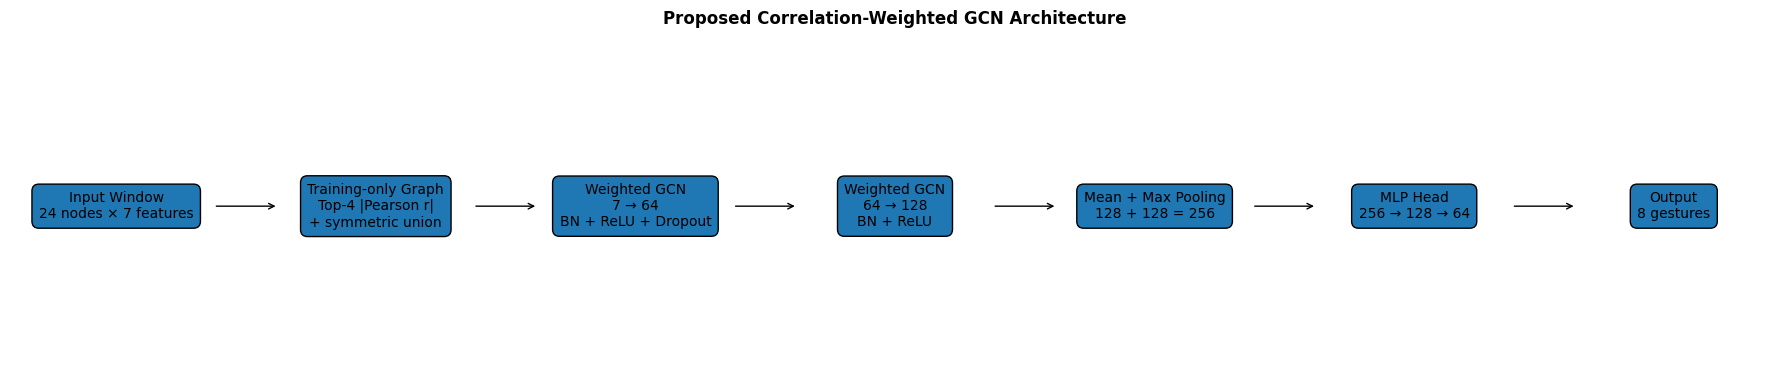

In [7]:
# Architecture diagram required for Task 2

fig, ax = plt.subplots(figsize=(18, 4))
ax.axis("off")

blocks = [
    "Input Window\n24 nodes × 7 features",
    "Training-only Graph\nTop-4 |Pearson r|\n+ symmetric union",
    "Weighted GCN\n7 → 64\nBN + ReLU + Dropout",
    "Weighted GCN\n64 → 128\nBN + ReLU",
    "Mean + Max Pooling\n128 + 128 = 256",
    "MLP Head\n256 → 128 → 64",
    "Output\n8 gestures",
]

xs = np.linspace(0.06, 0.94, len(blocks))

for i, (x, label) in enumerate(zip(xs, blocks)):
    ax.text(
        x, 0.5, label,
        ha="center", va="center",
        transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.5")
    )

    if i < len(blocks) - 1:
        ax.annotate(
            "",
            xy=(xs[i + 1] - 0.055, 0.5),
            xytext=(x + 0.055, 0.5),
            xycoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->")
        )

ax.set_title(
    "Proposed Correlation-Weighted GCN Architecture",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Cell 7 — Training


In [8]:
loss_fn = nn.NLLLoss(
    weight=cw_tensor.to(device)
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

EPOCHS = 100
PATIENCE = 20

best_val_f1 = -np.inf
best_state = None
best_epoch = 0
patience_ctr = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_macro_f1": []
}


# One complete train / validation epoch
def run_epoch(loader, training=True):

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    context = (
        torch.enable_grad()
        if training
        else torch.no_grad()
    )

    with context:

        for batch in loader:

            batch = batch.to(device)

            out = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr.squeeze(1),
                batch.batch
            )

            loss = loss_fn(
                out,
                batch.y
            )

            if training:

                optimizer.zero_grad()

                loss.backward()

                optimizer.step()

            total_loss += loss.item()

            all_preds.append(
                out.argmax(dim=1)
                .detach()
                .cpu()
                .numpy()
            )

            all_labels.append(
                batch.y
                .detach()
                .cpu()
                .numpy()
            )

    avg_loss = total_loss / len(loader)

    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)

    return avg_loss, preds, labels


# Train model
print(
    f"Training up to {EPOCHS} epochs "
    f"(early-stop patience={PATIENCE}) ..."
)

t_start = time.time()


for epoch in range(1, EPOCHS + 1):

    # Train
    train_loss, _, _ = run_epoch(
        train_loader,
        training=True
    )

    # Validation
    val_loss, val_preds, val_labels = run_epoch(
        val_loader,
        training=False
    )

    val_f1 = f1_score(
        val_labels,
        val_preds,
        average="macro",
        zero_division=0
    )


    # Store history
    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_macro_f1"].append(
        val_f1
    )


    # LR scheduler
    scheduler.step(
        val_f1
    )


    # Best-checkpoint logic
    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        best_epoch = epoch

        best_state = {
            key: value.detach().cpu().clone()
            for key, value
            in model.state_dict().items()
        }

        patience_ctr = 0

    else:

        patience_ctr += 1


    # Progress output
    if (
        epoch == 1
        or epoch % 10 == 0
        or patience_ctr >= PATIENCE
    ):

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_macro_f1={val_f1:.4f} | "
            f"best={best_val_f1:.4f} | "
            f"lr={current_lr:.2e} | "
            f"patience={patience_ctr}/{PATIENCE}"
        )


    # Early stopping
    if patience_ctr >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break


# Restore best validation checkpoint
assert best_state is not None, (
    "No valid model checkpoint was saved."
)

model.load_state_dict(
    best_state
)

model = model.to(device)


# Final training summary
elapsed_minutes = (
    time.time() - t_start
) / 60.0

print("\nTraining complete.")

print(
    f"Best epoch        : {best_epoch}"
)

print(
    f"Best val Macro-F1 : {best_val_f1:.4f}"
)

print(
    f"Training time     : "
    f"{elapsed_minutes:.1f} min"
)


# Save best checkpoint
torch.save(
    {
        "model_state": best_state,

        "edge_index": edge_index.cpu(),

        "edge_weight": edge_weight.cpu(),

        "corr_matrix": corr_matrix,

        "label_classes": [
            int(c)
            for c in le.classes_
        ],

        "top_k": int(TOP_K),

        "best_epoch": int(best_epoch),

        "best_val_macro_f1": float(
            best_val_f1
        ),
    },
    OUTPUT_FOLDER / "corr_gcn_best.pth"
)

print(
    "Model saved → "
    "task2_proposed/corr_gcn_best.pth"
)

Training up to 100 epochs (early-stop patience=20) ...
Epoch 001 | train_loss=1.6884 | val_loss=1.7083 | val_macro_f1=0.3078 | best=0.3078 | lr=1.00e-03 | patience=0/20
Epoch 010 | train_loss=1.4424 | val_loss=1.7070 | val_macro_f1=0.3616 | best=0.3648 | lr=1.00e-03 | patience=3/20
Epoch 020 | train_loss=1.3676 | val_loss=1.6871 | val_macro_f1=0.3669 | best=0.3821 | lr=5.00e-04 | patience=7/20
Epoch 030 | train_loss=1.3279 | val_loss=1.7376 | val_macro_f1=0.3698 | best=0.3821 | lr=2.50e-04 | patience=17/20
Epoch 033 | train_loss=1.3200 | val_loss=1.7227 | val_macro_f1=0.3694 | best=0.3821 | lr=1.25e-04 | patience=20/20

Early stopping at epoch 33.

Training complete.
Best epoch        : 13
Best val Macro-F1 : 0.3821
Training time     : 14.0 min
Model saved → task2_proposed/corr_gcn_best.pth


## Cell 8 — Training Curves

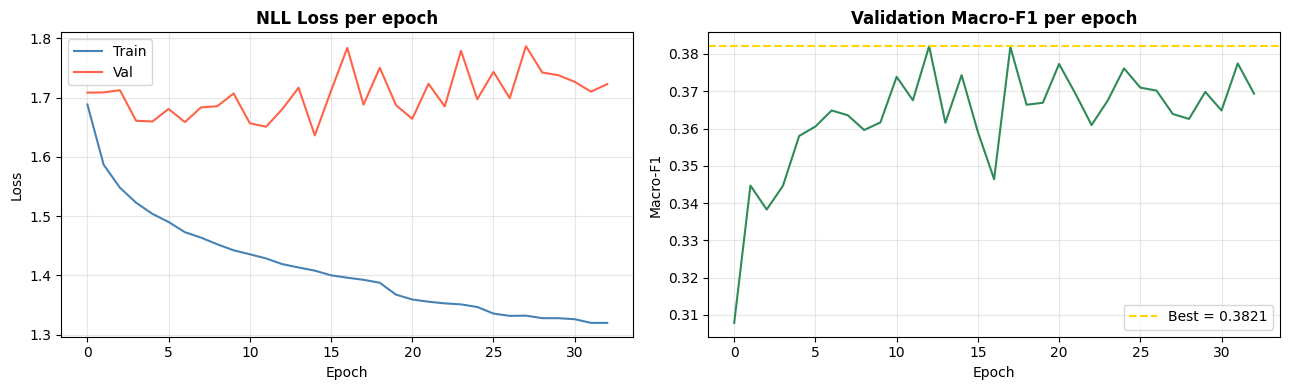

Best Macro-F1 reached at epoch 13 / 33


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="Train", color="steelblue")
axes[0].plot(history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("NLL Loss per epoch", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["val_macro_f1"], color="seagreen")
axes[1].axhline(best_val_f1, color="gold", linestyle="--",
                label=f"Best = {best_val_f1:.4f}")
axes[1].set_title("Validation Macro-F1 per epoch", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro-F1")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Best Macro-F1 reached at epoch "
      f"{np.argmax(history['val_macro_f1']) + 1} / {len(history['val_macro_f1'])}")


## Cell 9 — Evaluation on Validation Set

All baselines were evaluated on the same validation subjects.  
The GNN is evaluated the same way — test set still frozen.


  Corr-GCN — Validation Results
  Accuracy          : 0.5968
  Balanced Accuracy : 0.4242
  Macro-F1          : 0.3821  ← primary metric
  Macro Precision   : 0.3721
  Macro Recall      : 0.4242
  Weighted-F1       : 0.6286
  Weighted Precision: 0.6896
  Weighted Recall   : 0.5968
  ROC-AUC (macro)   : 0.7905
  PR-AUC  (macro)   : 0.3734

              precision    recall  f1-score   support

        Idle       0.94      0.73      0.82     52364
        Fist       0.23      0.59      0.34      4913
     Flexion       0.36      0.52      0.43      4825
   Extension       0.61      0.77      0.68      4706
 Pinch-Index       0.21      0.21      0.21      4723
Pinch-Middle       0.22      0.14      0.17      4577
  Pinch-Ring       0.09      0.14      0.11      4489
 Pinch-Small       0.32      0.29      0.30      4680

    accuracy                           0.60     85277
   macro avg       0.37      0.42      0.38     85277
weighted avg       0.69      0.60      0.63     85277



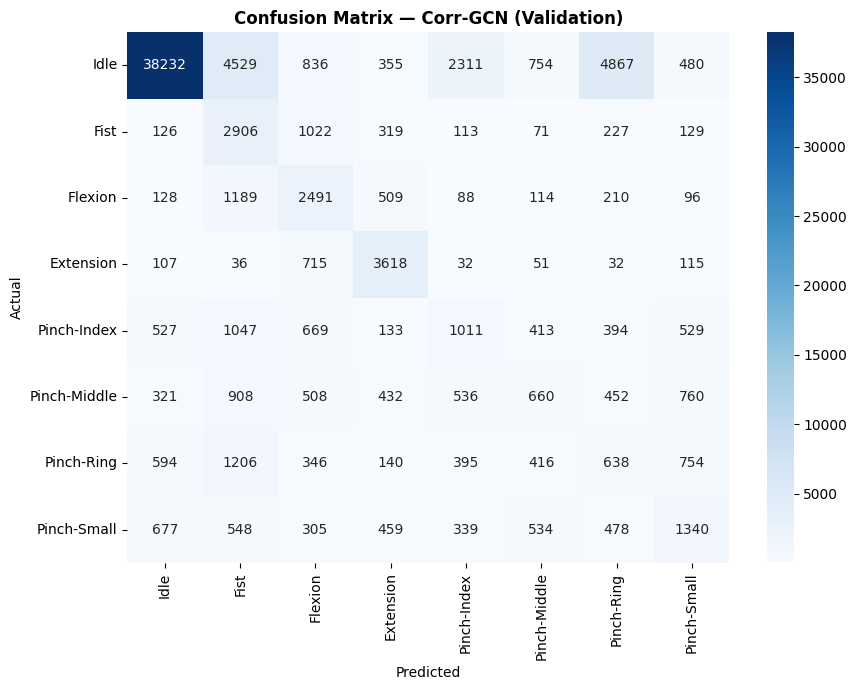

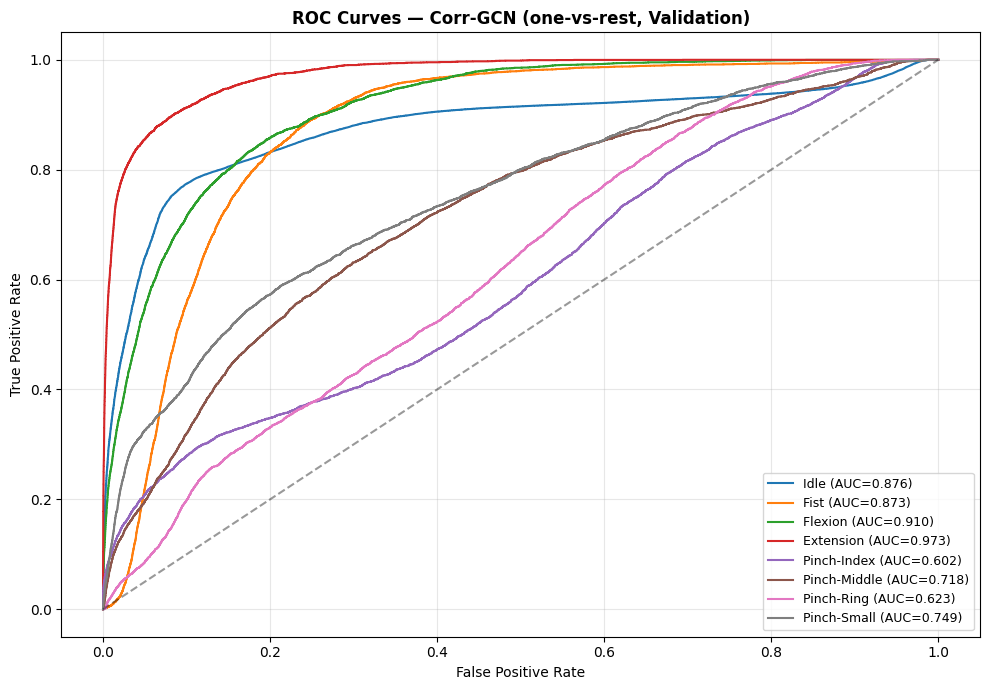

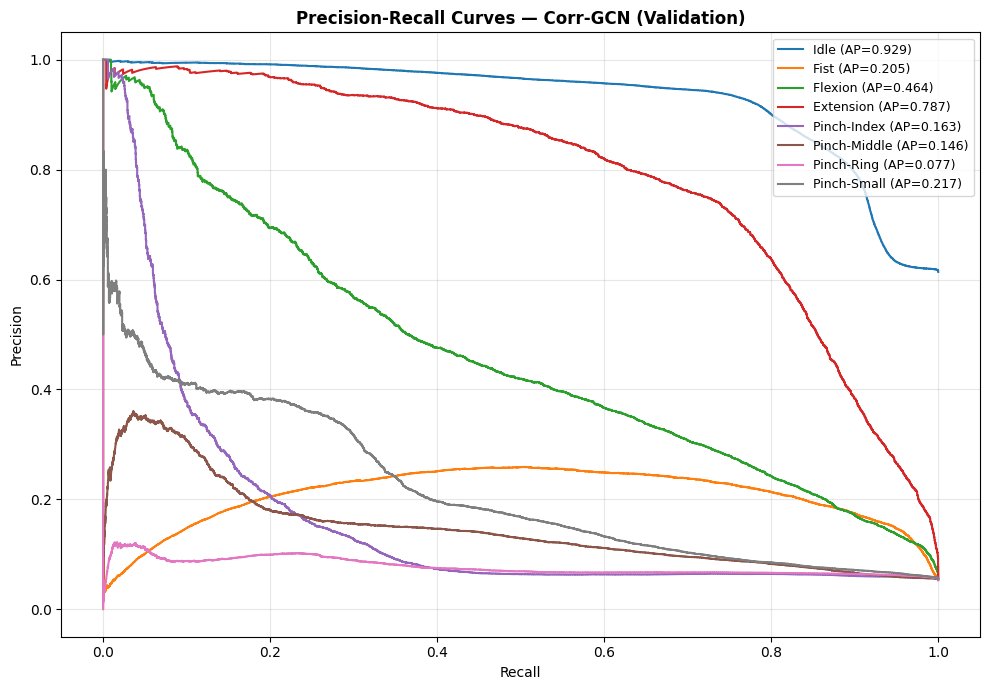

Saved → task2_proposed/gnn_val_results.json


In [10]:
model.eval()
val_preds, val_probas, val_labels = [], [], []

with torch.no_grad():
    for batch in val_loader:
        batch  = batch.to(device)
        logits = model(batch.x, batch.edge_index,
                       batch.edge_attr.squeeze(1), batch.batch)
        probs  = torch.exp(logits)   # log_softmax → softmax
        val_preds.append(logits.argmax(dim=1).cpu().numpy())
        val_probas.append(probs.cpu().numpy())
        val_labels.append(batch.y.cpu().numpy())

y_pred  = np.concatenate(val_preds)
y_proba = np.concatenate(val_probas)
y_true  = np.concatenate(val_labels)

#  Full metric set (same as baseline notebook) 
acc      = accuracy_score(y_true, y_pred)
bal_acc  = balanced_accuracy_score(y_true, y_pred)
mac_f1   = f1_score(y_true, y_pred, average="macro",    zero_division=0)
wgt_f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mac_prec = precision_score(y_true, y_pred, average="macro",    zero_division=0)
mac_rec  = recall_score(y_true, y_pred, average="macro",    zero_division=0)
wgt_prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
wgt_rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
roc_auc  = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
pr_auc   = average_precision_score(np.eye(n_classes)[y_true], y_proba, average="macro")

print("=" * 52)
print("  Corr-GCN — Validation Results")
print("=" * 52)
print(f"  Accuracy          : {acc:.4f}")
print(f"  Balanced Accuracy : {bal_acc:.4f}")
print(f"  Macro-F1          : {mac_f1:.4f}  ← primary metric")
print(f"  Macro Precision   : {mac_prec:.4f}")
print(f"  Macro Recall      : {mac_rec:.4f}")
print(f"  Weighted-F1       : {wgt_f1:.4f}")
print(f"  Weighted Precision: {wgt_prec:.4f}")
print(f"  Weighted Recall   : {wgt_rec:.4f}")
print(f"  ROC-AUC (macro)   : {roc_auc:.4f}")
print(f"  PR-AUC  (macro)   : {pr_auc:.4f}")
print()
print(classification_report(y_true, y_pred,
                              target_names=class_names, zero_division=0))

#  Confusion matrix 
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix — Corr-GCN (Validation)", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

#  ROC curves (one-vs-rest) 
y_bin = label_binarize(y_true, classes=list(range(n_classes)))
fig, ax = plt.subplots(figsize=(10, 7))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    auc_i = roc_auc_score(y_bin[:, i], y_proba[:, i])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_i:.3f})")
ax.plot([0,1],[0,1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Corr-GCN (one-vs-rest, Validation)", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

#  PR curves 
from sklearn.metrics import precision_recall_curve, average_precision_score
fig, ax = plt.subplots(figsize=(10, 7))
for i, name in enumerate(class_names):
    prec_c, rec_c, _ = precision_recall_curve(y_bin[:, i], y_proba[:, i])
    ap_i = average_precision_score(y_bin[:, i], y_proba[:, i])
    ax.plot(rec_c, prec_c, label=f"{name} (AP={ap_i:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Corr-GCN (Validation)", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

gnn_results = {
    "Model"             : "Corr-GCN (GNN)",
    "Accuracy"          : round(acc,     4),
    "Balanced Accuracy" : round(bal_acc, 4),
    "Macro-F1"          : round(mac_f1,  4),
    "Macro Precision"   : round(mac_prec,4),
    "Macro Recall"      : round(mac_rec, 4),
    "Weighted-F1"       : round(wgt_f1,  4),
    "Weighted Precision": round(wgt_prec,4),
    "Weighted Recall"   : round(wgt_rec, 4),
    "ROC-AUC"           : round(roc_auc, 4),
    "PR-AUC"            : round(pr_auc,  4),
    "Train time (s)"    : round(elapsed_minutes * 60, 1),
}

with open(OUTPUT_FOLDER / "gnn_val_results.json", "w") as f:
    json.dump(gnn_results, f, indent=2)

print("Saved → task2_proposed/gnn_val_results.json")

## Cell 10 — Comparison: Corr-GCN vs All Baselines

Baseline to beat is loaded automatically from `baseline_results.csv`
using validation Macro-F1.


Baseline to beat: MLP (PyTorch)  (Macro-F1 = 0.5346)


,Model,Accuracy,Balanced Accuracy,Macro-F1,ROC-AUC,PR-AUC,Train time (s)
1,MLP (PyTorch),0.6184,0.6415,0.5346,0.8962,0.6500,305.4
2,Random Forest,0.7287,0.5312,0.5244,0.9061,0.5929,652.3
3,LightGBM,0.6393,0.6001,0.5100,0.8886,0.5954,163.4
4,XGBoost,0.6414,0.5977,0.5088,0.8897,0.5969,196.4
5,1D-CNN (PyTorch),0.6205,0.5850,0.5002,0.8738,0.5867,179.7
6,Gradient Boosting,0.6404,0.5826,0.4994,0.8813,0.5657,8525.4
7,SVM (RBF),0.6636,0.4981,0.4646,0.8683,0.4844,5192.9
8,k-NN (k=5),0.6742,0.4565,0.4436,0.7728,0.3805,0.3
9,Decision Tree,0.5338,0.4723,0.4038,0.6858,0.2857,172.1
10,Corr-GCN (GNN),0.5968,0.4242,0.3821,0.7905,0.3734,837.5


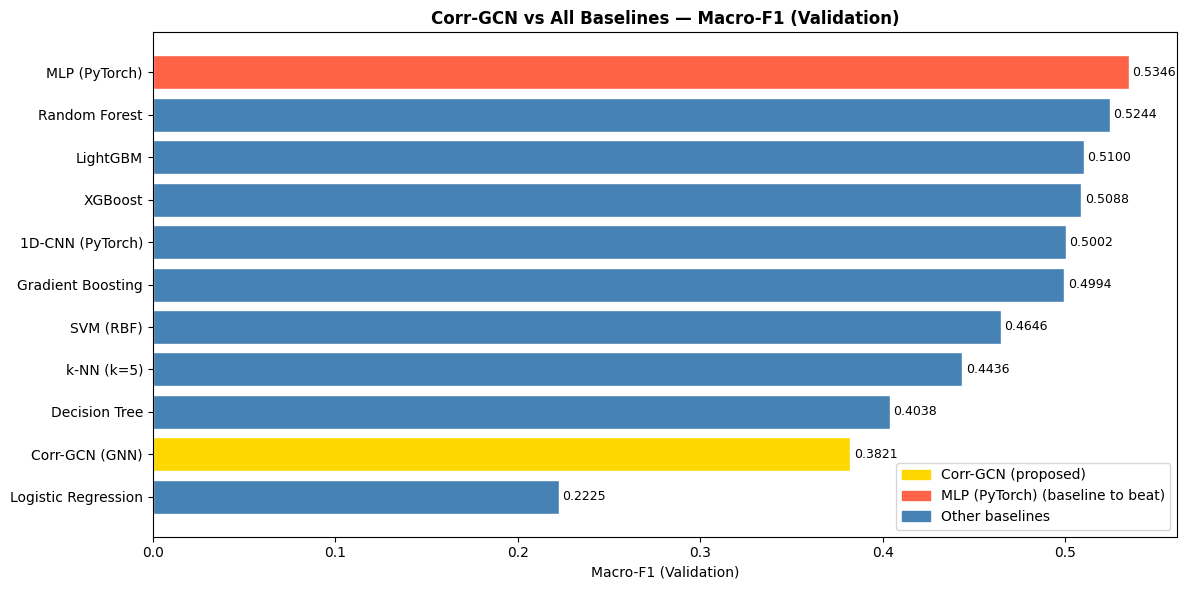


Baseline to beat (MLP (PyTorch)) Macro-F1 : 0.5346
Corr-GCN Macro-F1                              : 0.3821

-> Corr-GCN achieved 0.1525 lower validation Macro-F1 than MLP (PyTorch).

Saved -> task2_proposed/full_comparison.csv
Test set is still FROZEN. Final test evaluation will be performed in Task 3.


In [11]:
# Find the best baseline by Macro-F1
best_baseline     = baseline_df.loc[baseline_df["Macro-F1"].idxmax()]
baseline_best_f1  = float(best_baseline["Macro-F1"])
baseline_best_name = str(best_baseline["Model"])

print(f"Baseline to beat: {baseline_best_name}  (Macro-F1 = {baseline_best_f1:.4f})")

gnn_row     = gnn_results.copy()
all_results = baseline_df.to_dict("records") + [gnn_row]
compare_df  = pd.DataFrame(all_results).sort_values("Macro-F1", ascending=False)
compare_df  = compare_df.reset_index(drop=True)
compare_df.index += 1

cols_show = ["Model", "Accuracy", "Balanced Accuracy", "Macro-F1",
             "ROC-AUC", "PR-AUC", "Train time (s)"]
display(compare_df[cols_show].fillna("—"))

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["gold"      if "GCN" in str(m) else
          "tomato"    if m == baseline_best_name else "steelblue"
          for m in compare_df["Model"]]
ax.barh(compare_df["Model"], compare_df["Macro-F1"],
        color=colors, edgecolor="white")
ax.set_xlabel("Macro-F1 (Validation)")
ax.set_title("Corr-GCN vs All Baselines — Macro-F1 (Validation)",
             fontweight="bold")
ax.invert_yaxis()
for i, v in enumerate(compare_df["Macro-F1"]):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="gold",      label="Corr-GCN (proposed)"),
    Patch(color="tomato",    label=f"{baseline_best_name} (baseline to beat)"),
    Patch(color="steelblue", label="Other baselines"),
], loc="lower right")
plt.tight_layout(); plt.show()

# ── Result statement ──────────────────────────────────────────────────────────
gnn_f1 = gnn_results["Macro-F1"]
print(f"\nBaseline to beat ({baseline_best_name}) Macro-F1 : {baseline_best_f1:.4f}")
print(f"Corr-GCN Macro-F1                              : {gnn_f1:.4f}")
print()
diff = gnn_f1 - baseline_best_f1

if diff > 0:
    print(
        f"-> Corr-GCN achieved {diff:.4f} higher "
        f"validation Macro-F1 than {baseline_best_name}."
    )
elif diff < 0:
    print(
        f"-> Corr-GCN achieved {abs(diff):.4f} lower "
        f"validation Macro-F1 than {baseline_best_name}."
    )
else:
    print(
        "-> Corr-GCN and the best baseline have the same "
        "reported validation Macro-F1."
    )


compare_df.to_csv(OUTPUT_FOLDER / "full_comparison.csv", index=False)
print("\nSaved -> task2_proposed/full_comparison.csv")
print("Test set is still FROZEN. Final test evaluation will be performed in Task 3.")

## Corr-GCN Model Explanation

### 1. Step-by-step model operation

Each EMG window is represented as a graph containing **24 nodes**, where each node represents one EMG electrode. Each electrode has seven statistical features:

**MAV, RMS, STD, VAR, WL, ZC, and SSC.**

Therefore, one original 168-dimensional feature vector is reorganized into a **24 × 7 node-feature matrix**.

The graph structure is constructed using the **training subjects only**. Pearson correlation is calculated between the MAV values of the 24 electrodes across the training windows. The absolute correlation value, |r|, is used as the strength of the relationship between two electrodes.

Each electrode initially selects its **four strongest correlated electrodes (Top-K = 4)**. These selections are then symmetrized. Therefore, the final degree of a node can be greater than four if other electrodes also select that node. The correlation strength is retained as the edge weight. Self-loops are handled by the GCN layer.

The node features are then passed through two weighted graph convolution layers:

- GCN Layer 1: **7 → 64**
- GCN Layer 2: **64 → 128**

During graph convolution, each electrode updates its representation using information from connected electrodes. After two GCN layers, the node representations contain information from their local graph neighbourhood.

The 24 node representations are then converted into one graph-level representation using **global mean pooling and global max pooling**. Each pooling operation produces 128 values, giving a combined **256-dimensional representation**.

Finally, the classification head applies:

**256 → 128 → 64 → 8 classes**

to predict one of the eight gesture classes.

### 2. Design choices

**Correlation-based graph:**  
The purpose of the graph is to explicitly represent relationships between EMG channels. For this first Task 2 model, a training-only Pearson-correlation graph provides a simple and reproducible functional relationship between electrodes. DTF/MVAR requires the original multichannel time-series representation and is therefore deferred to the graph-construction experiments in Task 3.

**Absolute correlation:**  
Both strong positive and strong negative correlations indicate strong relationships between channels. Therefore, |r| is used for neighbour selection and edge weighting.

**Top-K = 4:**  
Using only the strongest relationships keeps the graph relatively sparse and avoids including every weak correlation as an edge. The effect of different Top-K values will be evaluated later rather than being tuned using the Task 2 result.

**Mean and max pooling:**  
Mean pooling summarizes the overall node representation across the graph, while max pooling preserves the strongest learned node response. Combining both provides complementary graph-level information.

**Class-weighted loss:**  
The gesture classes are imbalanced, particularly because the Idle class contains many more windows. Class weights are calculated from the training labels only so that errors on minority gesture classes receive greater importance during optimization.

**AdamW and learning-rate scheduling:**  
AdamW is used as the optimizer with weight decay as regularization. `ReduceLROnPlateau` reduces the learning rate when validation Macro-F1 stops improving.

**Early stopping:**  
Validation Macro-F1 is used for checkpoint selection because Macro-F1 is also the primary comparison metric for this project. Training can continue for at most 100 epochs, with early stopping after 20 consecutive epochs without improvement. The checkpoint with the highest validation Macro-F1 is restored after training.

### 3. Expected advantage over the flat baselines

The baseline models receive the window as a flat feature vector. Some baselines, especially MLP and tree-based models, can learn interactions among these features, but they do not explicitly represent the electrodes as nodes or perform message passing over an electrode graph.

Corr-GCN introduces this additional structure by allowing information to propagate between strongly related EMG channels. This gives the model an explicit mechanism for learning multi-electrode activation patterns.

This is a potential advantage rather than a guarantee that the GCN will outperform the best baseline.

### 4. Interpretation of the Task 2 result

The Task 2 result should be interpreted using validation Macro-F1 and the other evaluation metrics.

If Corr-GCN performs better than the best baseline, the result provides initial evidence that explicitly modelling inter-channel relationships may be useful.

If Corr-GCN performs similarly or worse, the result is still useful. It establishes the first GNN result and provides a controlled starting point for Task 3, where graph construction, GNN architecture, neighbourhood size, and other design choices will be evaluated systematically.

The untouched test subjects are not used for Task 2 model selection. Final test evaluation is reserved for Task 3 after the model configuration has been selected.

## Cell 11 — Save Summary

In [12]:
# Cell 11 — Save Task 2 Proposed-Model Summary

summary = {
    "model": "Corr-GCN",

    "graph": {
        "nodes": int(N_CHANNELS),
        "node_features": int(N_METRICS),
        "construction": "training-only absolute Pearson correlation of MAV",
        "top_k_selected": int(TOP_K),
        "symmetrization": "union using maximum edge weight",
        "edge_weight": "absolute Pearson correlation"
    },

    "architecture": {
        "gcn_hidden_dims": [64, 128],
        "pooling": "global mean + global max",
        "classifier_dims": [256, 128, 64, int(n_classes)],
        "dropout": 0.3
    },

    "training": {
        "optimizer": "AdamW",
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
        "max_epochs": 100,
        "epochs_trained": int(len(history["train_loss"])),
        "best_epoch": int(best_epoch),
        "early_stopping_patience": 20,
        "primary_metric": "validation Macro-F1"
    },

    "best_validation_result": {
        "macro_f1": round(float(best_val_f1), 4)
    },

    "baseline_to_beat": {
        "model": baseline_best_name,
        "macro_f1": round(float(baseline_best_f1), 4)
    },

    "validation_metrics": gnn_results,

    "test_evaluated": False
}

with open(
    OUTPUT_FOLDER / "task2_proposed_summary.json",
    "w"
) as f:
    json.dump(summary, f, indent=2)

print(
    f"Saved -> "
    f"{OUTPUT_FOLDER / 'task2_proposed_summary.json'}"
)

print(f"\nBest epoch                : {best_epoch}")
print(f"Best validation Macro-F1 : {best_val_f1:.4f}")
print(
    f"Baseline to beat "
    f"({baseline_best_name}) : "
    f"{baseline_best_f1:.4f}"
)

print(
    "Test set is FROZEN. "
    "Final test evaluation will be performed in Task 3."
)

Saved -> /kaggle/working/task2_proposed/task2_proposed_summary.json

Best epoch                : 13
Best validation Macro-F1 : 0.3821
Baseline to beat (MLP (PyTorch)) : 0.5346
Test set is FROZEN. Final test evaluation will be performed in Task 3.


## Task 3 — Planned Improvements and Final Evaluation

Task 2 establishes the initial Corr-GCN configuration and compares it with the baseline models. Task 3 will evaluate whether the GNN can be improved using controlled experiments.

### 1. Subject-grouped cross-validation

Model development will use **5-fold subject-grouped cross-validation** so that windows from the same subject never appear in both the training and validation portions of a fold.

For every fold:

- preprocessing will be fitted using the fold-training subjects only;
- graph construction will use the fold-training subjects only;
- validation subjects will not influence preprocessing or graph construction.

The models will be compared using mean ± standard deviation across the five folds, with **Macro-F1 as the primary metric**.

### 2. Graph-construction ablation

The first Task 2 graph uses absolute Pearson correlation with Top-K = 4.

Task 3 will test alternative graph definitions where feasible, including:

- correlation-based graph;
- physical-neighbour graph;
- DTF/MVAR-based functional graph using the original multichannel EMG signals.

The purpose is to determine whether performance changes because of the way electrode relationships are represented.

### 3. Neighbourhood-size ablation

The effect of graph sparsity will be evaluated using different Top-K values, for example:

- K = 2
- K = 4
- K = 6
- K = 8

The Task 2 value of K = 4 serves as the reference configuration.

### 4. GNN architecture comparison

Alternative graph neural-network layers will be compared, including:

- GCN
- GraphSAGE
- GAT

This will test whether alternative aggregation or attention mechanisms improve subject-independent gesture recognition.

### 5. Feature ablation

The current model uses seven node features:

MAV, RMS, STD, VAR, WL, ZC, and SSC.

Task 3 can compare this representation with alternatives such as including IEMG or other justified feature combinations. Because IEMG is deterministically related to MAV for the fixed window length, the seven-feature representation remains the primary configuration.

### 6. Architecture and training tuning

A limited, controlled search will examine settings such as:

- hidden dimensions;
- number of GNN layers;
- dropout;
- learning rate;
- pooling method;
- normalization.

Configuration selection will use the grouped development folds only.

### 7. Statistical comparison

The selected GNN will be compared with the selected best baseline using the same subject-grouped folds.

Fold-wise results will be used for a paired statistical comparison, such as the **Wilcoxon signed-rank test**, where appropriate.

### 8. Explainability

The final model will be examined using:

- SHAP;
- LIME;
- correctly classified examples;
- incorrectly classified examples.

Interpretation will focus on which electrode-feature combinations contribute to gesture predictions.

### 9. Final test evaluation

The test subjects remain untouched during Task 2 and Task 3 model selection.

After the final model configuration has been selected, it will be trained using the defined development protocol and evaluated on the held-out test subjects.

This will be the final test evaluation.